# 🎓 Student Academic Prediction — Full ML Pipeline (v3, corrected)

Dataset: `student_performance_updated_1000.csv`  
Tasks: Regression (predict `FinalGrade`) · Classification (predict Pass/Fail)  
Models: Linear · Ridge · Lasso · Decision Tree · Random Forest · Gradient Boosting · XGBoost · SVR  
Extras: Hyperparameter tuning · SHAP · Learning curves · Error analysis · **model saving**

### What changed from v2 (see inline comments for details at each fix)
1. **Leakage fix** — categorical mode-imputation and encoding now happen *after* the train/test split, using train-only statistics.
2. **Real stratified split** — v2 claimed a stratified split in a comment but never actually passed `stratify=`. This version genuinely stratifies on grade quartile bins.
3. **Ordinal encoding fix** — `ParentalSupport` now uses an explicit `{Low:0, Medium:1, High:2}` map instead of `LabelEncoder`, which assigned meaningless alphabetical integers that linear models would have misread as a real scale.
4. **Fixed pass/fail threshold** — a documented constant (`PASS_THRESHOLD`) instead of `y_train.median()`, which shifted with `random_state` and wasn't tied to any real grading policy.
5. **Tuning is no longer discarded** — the Step 7 hyperparameter-tuned model now actually competes in the leaderboard and can become `best_reg`, instead of being computed and ignored.
6. **Duplicate-student check added** — `StudentID` duplicates are now detected and removed before being dropped as an identifier column.
7. **Removed deprecated `use_label_encoder=False`** from `XGBClassifier` (unsupported in xgboost ≥ 1.6).
8. **New: models, scaler, imputer, and all metrics are saved to disk** (`models/`, `exports/`) — v2 never persisted anything, so nothing could be reused outside the notebook.

In [1]:
# ─────────────────────────────────────────────────────────────
# STEP 1 ▸ Imports
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RandomizedSearchCV, learning_curve)
from sklearn.linear_model    import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree            import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble        import (RandomForestRegressor, GradientBoostingRegressor,
                                     RandomForestClassifier, GradientBoostingClassifier)
from sklearn.svm             import SVR
from xgboost                 import XGBRegressor, XGBClassifier
from sklearn.metrics         import (r2_score, mean_squared_error, mean_absolute_error,
                                     accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score, roc_curve,
                                     confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling  import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3','#4CAF50','#FF9800','#E53935','#9C27B0','#00BCD4','#FF5722']
print("✓ All imports loaded")

# NOTE (fix): removed `use_label_encoder=False` from XGBClassifier below —
# that parameter was deprecated/removed in xgboost >= 1.6 and will raise
# a warning or error depending on your installed version.


✓ All imports loaded


## Step 2 — Load the dataset

In [2]:
# ─────────────────────────────────────────────────────────────
# STEP 2 ▸ Load the dataset
# ─────────────────────────────────────────────────────────────
df = pd.read_excel('../dataset/Student_Performance_Cleaned.xlsx')

print(f"\n{'='*55}")
print(f"  Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"{'='*55}")
print("\nColumn names and types:")
print(df.dtypes.to_string())
print("\nFirst 3 rows:")
print(df.head(3).to_string())
print("\nStatistical summary:")
print(df.describe().round(2).to_string())



  Dataset loaded: 950 rows × 13 columns

Column names and types:
Gender                           str
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport                  str
FinalGrade                     int64
Study Hours                  float64
Attendance (%)               float64
Online Classes Taken         float64
Attendance_Final             float64
StudyHours_Final             float64
Online_Classes                 int64

First 3 rows:
   Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  Study Hours  Attendance (%)  Online Classes Taken  Attendance_Final  StudyHours_Final  Online_Classes
0    Male            85.0               15.0           78.0                        1.0            High          80          4.8            59.0                   0.0              85.0              15.0               0
1 

## Step 3 — Data Cleaning
Row-wise / fixed-rule cleaning only. Anything that requires a *statistic* (mode, median) is deferred until after the split (Step 5) to avoid leakage.

In [3]:
# ─────────────────────────────────────────────────────────────
# STEP 3 ▸ Data Cleaning
# ─────────────────────────────────────────────────────────────
# FIXES in this version vs v2:
#   - Added a duplicate-StudentID check (v2 never checked this)
#   - StudentID is kept until AFTER the dedup check, then dropped
#     (v2 dropped it immediately, so duplicate students could never
#     be detected)
#   - Mode-imputation of categoricals and encoding are NOT done here
#     anymore — both are moved to after the train/test split (Step 5)
#     to avoid leaking test-set information into those statistics.
#     Everything still done in this cell (dropping rows, removing
#     impossible values, standardizing text, unifying duplicate
#     columns) is row-wise or a fixed rule, so it's safe to do before
#     the split.

print(f"\n{'='*55}")
print("  STEP 3 — DATA CLEANING")
print(f"{'='*55}")

df_clean = df.copy()
n0 = len(df_clean)

# 3-A: Drop rows where the target is missing
df_clean = df_clean[df_clean['FinalGrade'].notna()]
print(f"[3A] Removed {n0 - len(df_clean)} rows with missing FinalGrade")

# 3-B: Drop duplicate students (keep first occurrence), THEN drop identifiers
n1 = len(df_clean)
if 'StudentID' in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=['StudentID'], keep='first')
    print(f"[3B] Removed {n1 - len(df_clean)} duplicate-StudentID rows")
df_clean = df_clean.drop(
    columns=['StudentID', 'Name'],
    errors='ignore'
)
print("[3B] Dropped identifier columns (if present)")
# 3-C: Remove physically impossible values (drop, not cap)
n2 = len(df_clean)
impossible = (
    (df_clean['Attendance (%)'] > 100) |
    (df_clean['Study Hours']    < 0)
)
df_clean = df_clean[~impossible].reset_index(drop=True)
print(f"[3C] Removed {n2 - len(df_clean)} rows with impossible values "
      f"(Attendance > 100% or Study Hours < 0)")

# 3-D: Standardise text columns (fixed rule, not a data-derived statistic — safe pre-split)
df_clean['Gender']          = df_clean['Gender'].str.strip().str.title()
df_clean['ParentalSupport'] = df_clean['ParentalSupport'].str.strip().str.title()
print("[3D] Gender and ParentalSupport text standardised")

# 3-E: Unify duplicate feature columns
#       AttendanceRate and Attendance (%) — prefer AttendanceRate, fallback to Attendance (%)
#       StudyHoursPerWeek and Study Hours — prefer StudyHoursPerWeek, fallback to Study Hours
df_clean['Attendance_Final'] = df_clean['AttendanceRate'].where(
    df_clean['AttendanceRate'].notna(), df_clean['Attendance (%)']
)
df_clean['StudyHours_Final'] = df_clean['StudyHoursPerWeek'].where(
    df_clean['StudyHoursPerWeek'].notna(), df_clean['Study Hours']
)
df_clean = df_clean.drop(columns=['AttendanceRate', 'Attendance (%)',
                                   'StudyHoursPerWeek', 'Study Hours'])
print(f"[3E] Attendance_Final  non-null: {df_clean['Attendance_Final'].notna().sum()}")
print(f"[3E] StudyHours_Final  non-null: {df_clean['StudyHours_Final'].notna().sum()}")

# 3-F: Convert Online Classes Taken to 0/1
df_clean['Online_Classes'] = df_clean['Online Classes Taken'].map(
    {True: 1, False: 0}
).fillna(0).astype(int)
df_clean = df_clean.drop(columns=['Online Classes Taken'])

print(f"\nClean shape: {df_clean.shape}")
print("\nRemaining missing values (categoricals will be imputed AFTER the split):")
mv = df_clean.isnull().sum()
print(mv[mv > 0].to_string() if mv.any() else "  None — all columns complete")



  STEP 3 — DATA CLEANING
[3A] Removed 0 rows with missing FinalGrade
[3B] Dropped identifier columns (if present)
[3C] Removed 0 rows with impossible values (Attendance > 100% or Study Hours < 0)
[3D] Gender and ParentalSupport text standardised
[3E] Attendance_Final  non-null: 949
[3E] StudyHours_Final  non-null: 949

Clean shape: (950, 8)

Remaining missing values (categoricals will be imputed AFTER the split):
PreviousGrade                29
ExtracurricularActivities    39
Attendance_Final              1
StudyHours_Final              1


## Step 4 — Exploratory Data Analysis


  STEP 4 — EDA


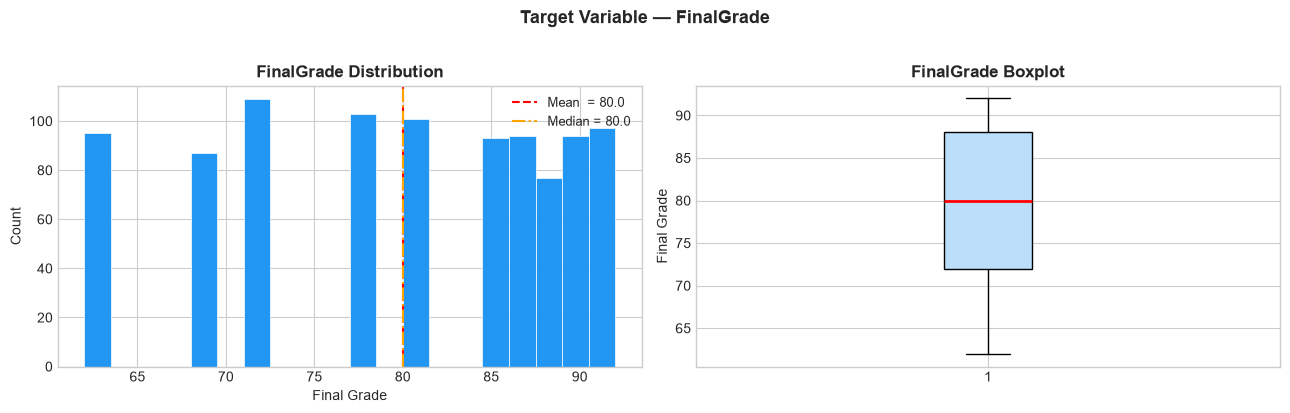

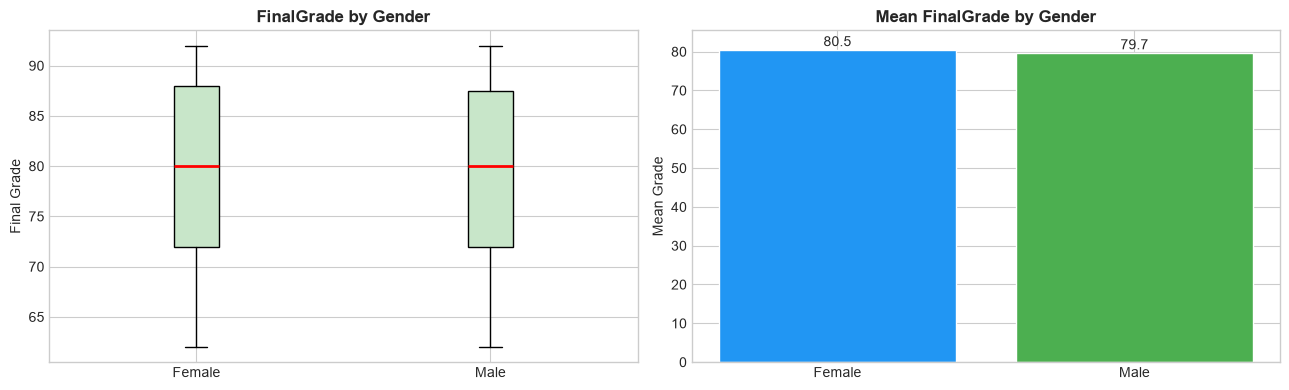

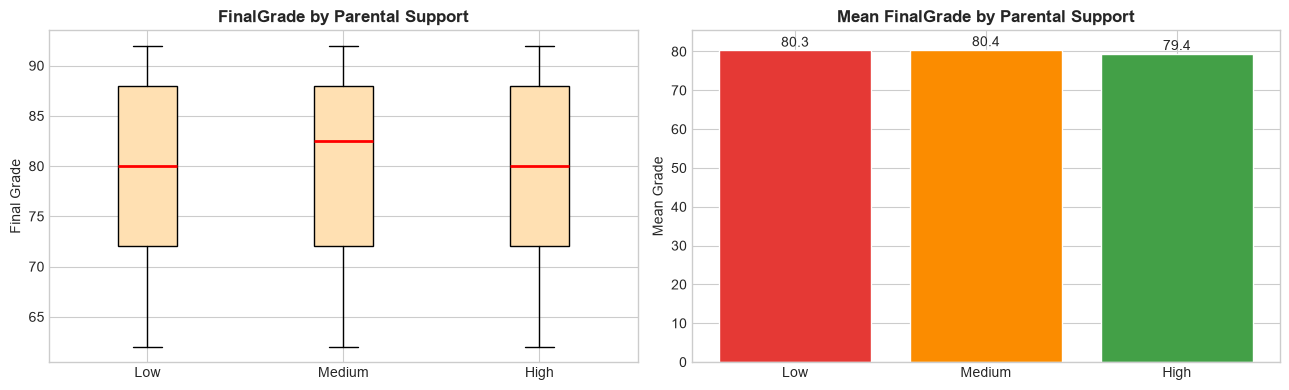

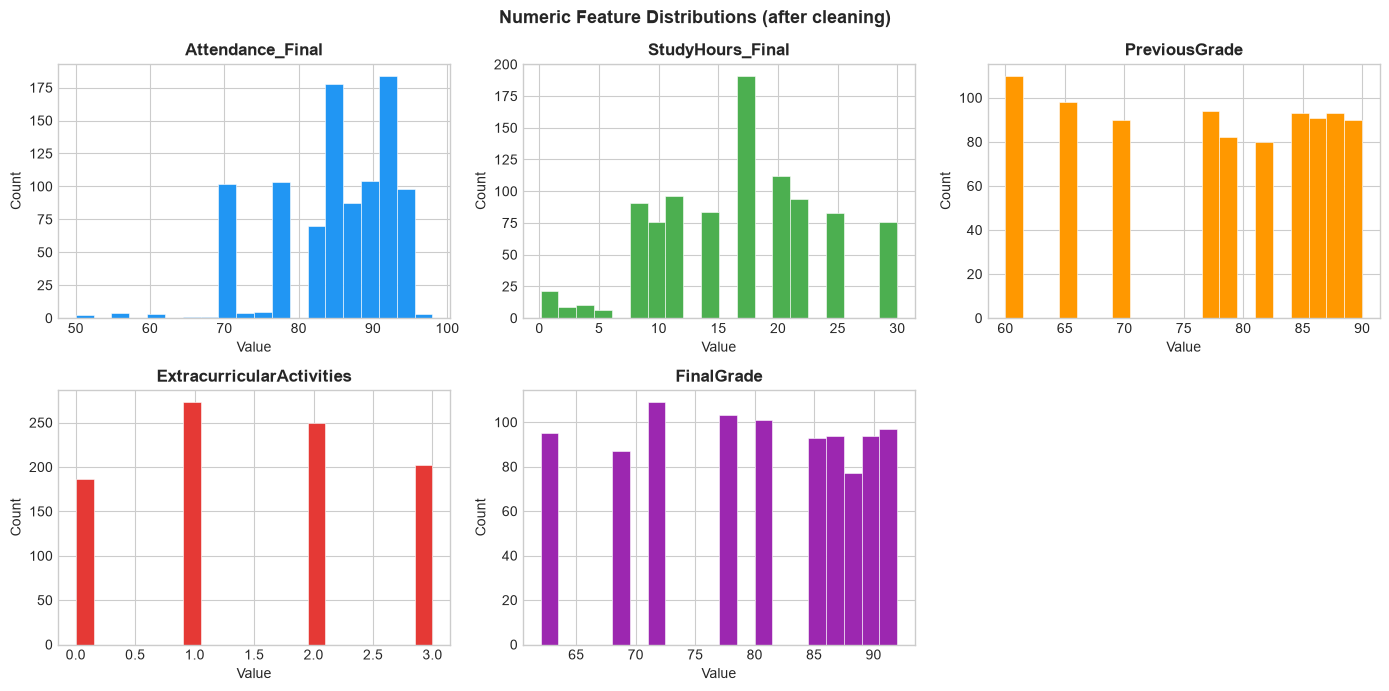

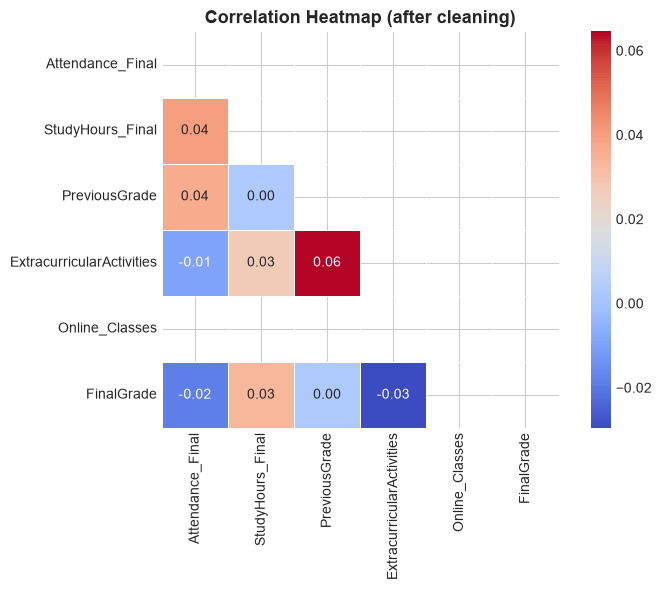


Correlations with FinalGrade:
  StudyHours_Final              : +0.0333
  ExtracurricularActivities     : -0.0296
  Attendance_Final              : -0.0184
  PreviousGrade                 : +0.0029
  Online_Classes                : +nan


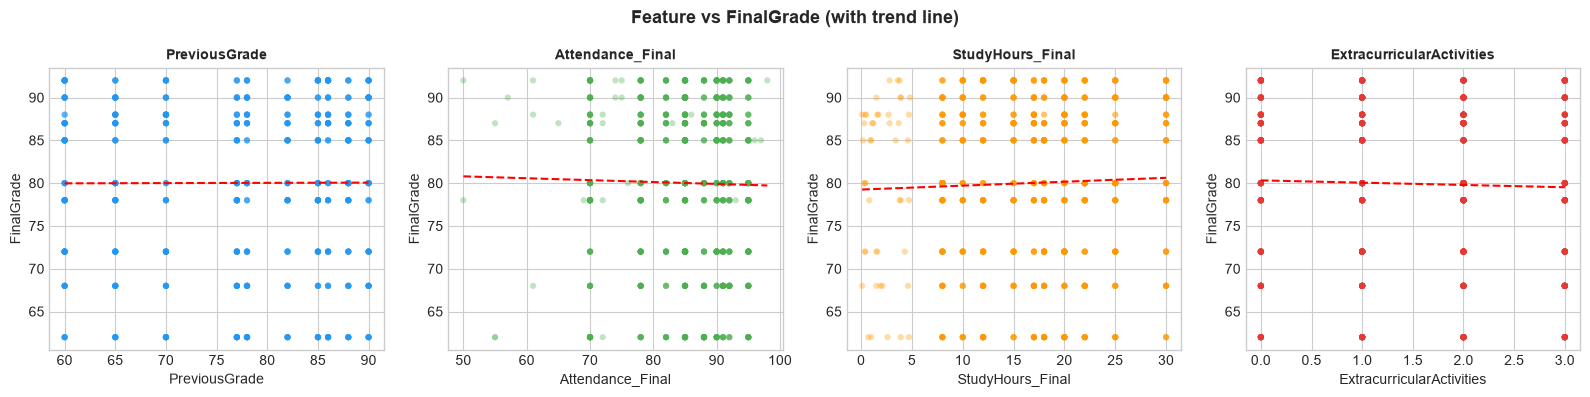

In [4]:
# ─────────────────────────────────────────────────────────────
# STEP 4 ▸ Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────
# Note: EDA here is purely descriptive (plots/correlations), not used to fit
# any model parameter, so doing it on the full cleaned dataset (pre-split)
# is fine — this is different from imputation/scaling/encoding, which DO
# leak information if fit before the split.
#
# FIX (matplotlib compatibility): boxplot()'s `labels=` argument was
# renamed to `tick_labels=` in matplotlib 3.9, and some installs have
# already dropped `labels` entirely (this is what threw the TypeError).
# Instead of relying on either name, we plot without a labels kwarg and
# set the tick labels manually with set_xticklabels() afterward — this
# works on every matplotlib version.

print(f"\n{'='*55}")
print("  STEP 4 — EDA")
print(f"{'='*55}")

# --- 4.1 Target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_clean['FinalGrade'], bins=20,
             color=PALETTE[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(df_clean['FinalGrade'].mean(),   color='red',
                linewidth=1.5, linestyle='--', label=f"Mean  = {df_clean['FinalGrade'].mean():.1f}")
axes[0].axvline(df_clean['FinalGrade'].median(), color='orange',
                linewidth=1.5, linestyle='-.',  label=f"Median = {df_clean['FinalGrade'].median():.1f}")
axes[0].set_title('FinalGrade Distribution', fontweight='bold')
axes[0].set_xlabel('Final Grade'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

axes[1].boxplot(df_clean['FinalGrade'], patch_artist=True,
                boxprops=dict(facecolor='#BBDEFB'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('FinalGrade Boxplot', fontweight='bold')
axes[1].set_ylabel('Final Grade')
plt.suptitle('Target Variable — FinalGrade', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('eda_01_target.png', dpi=120, bbox_inches='tight'); plt.show()

# --- 4.2 Grade by Gender ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
genders = sorted(df_clean['Gender'].dropna().unique())
data_by_gender = [df_clean[df_clean['Gender'] == g]['FinalGrade'].dropna() for g in genders]
axes[0].boxplot(data_by_gender, patch_artist=True,
                boxprops=dict(facecolor='#C8E6C9'), medianprops=dict(color='red', linewidth=2))
axes[0].set_xticks(range(1, len(genders) + 1))
axes[0].set_xticklabels(genders)
axes[0].set_title('FinalGrade by Gender', fontweight='bold')
axes[0].set_ylabel('Final Grade')

means_g = df_clean.groupby('Gender')['FinalGrade'].mean().reindex(genders)
bars = axes[1].bar(genders, means_g, color=PALETTE[:len(genders)], edgecolor='white')
for bar, val in zip(bars, means_g):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Mean FinalGrade by Gender', fontweight='bold')
axes[1].set_ylabel('Mean Grade'); axes[1].set_ylim(0, means_g.max() + 5)
plt.tight_layout(); plt.savefig('eda_02_gender.png', dpi=120, bbox_inches='tight'); plt.show()

# --- 4.3 Grade by Parental Support ---
order = ['Low', 'Medium', 'High']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
data_by_ps = [df_clean[df_clean['ParentalSupport'] == p]['FinalGrade'].dropna() for p in order]
axes[0].boxplot(data_by_ps, patch_artist=True,
                boxprops=dict(facecolor='#FFE0B2'), medianprops=dict(color='red', linewidth=2))
axes[0].set_xticks(range(1, len(order) + 1))
axes[0].set_xticklabels(order)
axes[0].set_title('FinalGrade by Parental Support', fontweight='bold')
axes[0].set_ylabel('Final Grade')

means_ps = df_clean.groupby('ParentalSupport')['FinalGrade'].mean().reindex(order)
bars = axes[1].bar(order, means_ps, color=['#E53935','#FB8C00','#43A047'], edgecolor='white')
for bar, val in zip(bars, means_ps):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Mean FinalGrade by Parental Support', fontweight='bold')
axes[1].set_ylabel('Mean Grade'); axes[1].set_ylim(0, means_ps.max() + 5)
plt.tight_layout(); plt.savefig('eda_03_parental.png', dpi=120, bbox_inches='tight'); plt.show()

# --- 4.4 Numeric feature distributions ---
num_cols = ['Attendance_Final', 'StudyHours_Final', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col].dropna(), bins=20,
                 color=PALETTE[i % len(PALETTE)], edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontweight='bold'); axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count')
axes[-1].axis('off')
plt.suptitle('Numeric Feature Distributions (after cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_04_distributions.png', dpi=120, bbox_inches='tight'); plt.show()

# --- 4.5 Correlation heatmap ---
corr_cols = ['Attendance_Final', 'StudyHours_Final', 'PreviousGrade',
             'ExtracurricularActivities', 'Online_Classes', 'FinalGrade']
corr_matrix = df_clean[corr_cols].corr()
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap (after cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_05_heatmap.png', dpi=120, bbox_inches='tight'); plt.show()

print("\nCorrelations with FinalGrade:")
corr_fg = corr_matrix['FinalGrade'].drop('FinalGrade').sort_values(key=abs, ascending=False)
for feat, val in corr_fg.items():
    print(f"  {feat:30s}: {val:+.4f}")

# --- 4.6 Scatter plots vs FinalGrade ---
scatter_feats = ['PreviousGrade', 'Attendance_Final', 'StudyHours_Final', 'ExtracurricularActivities']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(scatter_feats):
    tmp = df_clean[[feat, 'FinalGrade']].dropna()
    axes[i].scatter(tmp[feat], tmp['FinalGrade'],
                    alpha=0.35, color=PALETTE[i], edgecolors='none', s=20)
    m, b = np.polyfit(tmp[feat], tmp['FinalGrade'], 1)
    x_line = np.linspace(tmp[feat].min(), tmp[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
    axes[i].set_xlabel(feat); axes[i].set_ylabel('FinalGrade')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
plt.suptitle('Feature vs FinalGrade (with trend line)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_06_scatter.png', dpi=120, bbox_inches='tight'); plt.show()


## Step 5 — Preprocessing
**This is the most changed section.** Split happens first; every statistic (mode, median, scaler mean/std) is fit on the training set only.

In [5]:
# ─────────────────────────────────────────────────────────────
# STEP 5 ▸ Preprocessing
# ─────────────────────────────────────────────────────────────
# FIXES in this version vs v2:
#   - Train/test split now happens FIRST, before any statistic (mode,
#     median, mean) is computed. v2 computed the categorical mode on
#     the full dataset, which leaks test-set information.
#   - Real stratification: v2's comment claimed a "stratified split on
#     grade bands" but the code didn't actually pass `stratify=`. This
#     version bins FinalGrade into quartiles and stratifies on that.
#   - ParentalSupport is now encoded with an explicit ordinal map
#     (Low=0, Medium=1, High=2) instead of LabelEncoder, which assigned
#     alphabetical integers (High=0, Low=1, Medium=2) — a meaningless
#     order that linear models (Linear/Ridge/Lasso/SVR) would have
#     wrongly treated as a real numeric scale.
#   - A fixed PASS_THRESHOLD constant is introduced here (used later in
#     Step 8) instead of "median of whatever ends up in the training
#     split", so the pass/fail definition is stable and documented.

print(f"\n{'='*55}")
print("  STEP 5 — PREPROCESSING")
print(f"{'='*55}")

PASS_THRESHOLD = 70.0   # <-- change this to match your course's real cutoff

GENDER_MAP  = {'Male': 0, 'Female': 1}
SUPPORT_MAP = {'Low': 0, 'Medium': 1, 'High': 2}   # ordinal, not alphabetical

# 5-A: Feature engineering that doesn't need imputed data can happen now
#      (interaction/ratio use numeric cols that may still have NaNs —
#      that's fine, NaN propagates and gets handled by the imputer below,
#      AFTER the split)
df_feat = df_clean.copy()
df_feat['Attendance_Study_Interaction'] = (
    df_feat['Attendance_Final'] * df_feat['StudyHours_Final']
)
df_feat['Grade_Study_Ratio'] = (
    df_feat['PreviousGrade'] / (df_feat['StudyHours_Final'] + 1)
)

FEATURE_COLS = [
    'Attendance_Final',
    'StudyHours_Final',
    'PreviousGrade',
    'ExtracurricularActivities',
    'Gender',              # still text here — encoded after split, train-safe (fixed map)
    'ParentalSupport',     # still text here — encoded after split, train-safe (fixed map)
    'Online_Classes',
    'Attendance_Study_Interaction',
    'Grade_Study_Ratio',
]

X = df_feat[FEATURE_COLS]
y = df_feat['FinalGrade']

# 5-B: Real stratified split — bin FinalGrade into quartiles so train/test
# have a representative spread of grades, then split on those bins
grade_bins = pd.qcut(y, q=4, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=grade_bins
)
X_train = X_train.copy()   # avoid SettingWithCopyWarning on the edits below
X_test  = X_test.copy()
print(f"Train set : {len(X_train)} rows")
print(f"Test  set : {len(X_test)} rows")

# 5-C: Impute categoricals with mode from TRAIN ONLY, apply to both
for col in ['Gender', 'ParentalSupport']:
    mode_val = X_train[col].mode()[0]
    n_train_filled = X_train[col].isna().sum()
    n_test_filled  = X_test[col].isna().sum()
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)
    if n_train_filled or n_test_filled:
        print(f"[5C] {col}: filled {n_train_filled} train / {n_test_filled} test "
              f"nulls with train mode → '{mode_val}'")

# 5-D: Encode with fixed ordinal/binary maps (safe to apply before or after
# split since these are fixed rules, not data-derived statistics)
X_train['Gender']          = X_train['Gender'].map(GENDER_MAP)
X_test['Gender']           = X_test['Gender'].map(GENDER_MAP)
X_train['ParentalSupport'] = X_train['ParentalSupport'].map(SUPPORT_MAP)
X_test['ParentalSupport']  = X_test['ParentalSupport'].map(SUPPORT_MAP)
print(f"[5D] Gender encoded  : {GENDER_MAP}")
print(f"[5D] Support encoded : {SUPPORT_MAP}  (ordinal, not alphabetical)")

# 5-E: Impute remaining numeric NaNs (fit on TRAIN only, transform both)
imputer        = SimpleImputer(strategy='median')
X_train_imp    = imputer.fit_transform(X_train)
X_test_imp     = imputer.transform(X_test)

# 5-F: Scale (fit on TRAIN only, transform both)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f"\nNaN in X_train_scaled : {np.isnan(X_train_scaled).sum()}")
print(f"NaN in X_test_scaled  : {np.isnan(X_test_scaled).sum()}")
print("✓ Preprocessing complete — ready for model training")



  STEP 5 — PREPROCESSING
Train set : 760 rows
Test  set : 190 rows
[5D] Gender encoded  : {'Male': 0, 'Female': 1}
[5D] Support encoded : {'Low': 0, 'Medium': 1, 'High': 2}  (ordinal, not alphabetical)

NaN in X_train_scaled : 0
NaN in X_test_scaled  : 0
✓ Preprocessing complete — ready for model training


## Step 6 — Regression Models


  STEP 6 — REGRESSION MODELS
  Linear Regression     Test R²=-0.0005  RMSE=9.7108  Overfit=0.0094
  Ridge (α=1)           Test R²=-0.0010  RMSE=9.7134  Overfit=0.0099
  Lasso (α=0.1)         Test R²=-0.0012  RMSE=9.7142  Overfit=0.0086
  Decision Tree         Test R²=-0.1603  RMSE=10.4575  Overfit=0.2320
  Random Forest         Test R²=-0.0363  RMSE=9.8832  Overfit=0.1394
  Gradient Boosting     Test R²=-0.1602  RMSE=10.4571  Overfit=0.4796
  XGBoost               Test R²=-0.2051  RMSE=10.6576  Overfit=0.5711
  SVR (RBF)             Test R²=-0.1384  RMSE=10.3586  Overfit=0.2603

─────────────────────────────────────────────────────────────────────────────────────
            Model  Train R²  Test R²  CV R² Mean  CV R² Std  Test RMSE  Test MAE  Overfit?
Linear Regression    0.0089  -0.0005     -0.0257     0.0126     9.7108    8.2755     False
      Ridge (α=1)    0.0089  -0.0010     -0.0249     0.0132     9.7134    8.2771     False
    Lasso (α=0.1)    0.0074  -0.0012     -0.0197     0

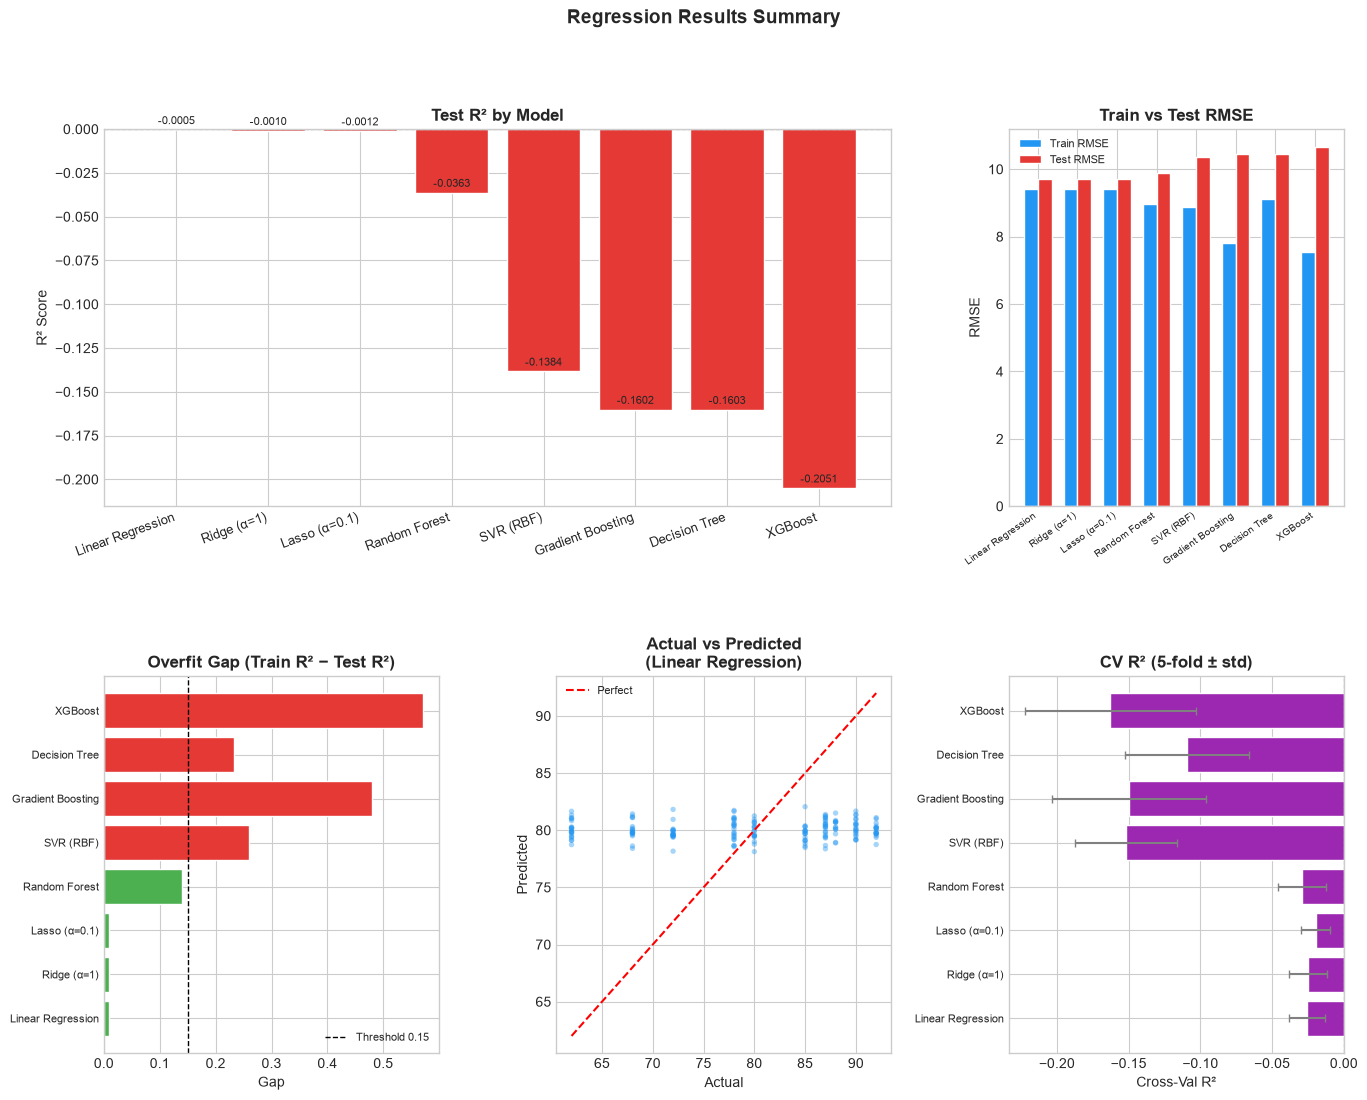

In [6]:
# ─────────────────────────────────────────────────────────────
# STEP 6 ▸ Regression Models
# ─────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  STEP 6 — REGRESSION MODELS")
print(f"{'='*55}")

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1)':       Ridge(alpha=1.0),
    'Lasso (α=0.1)':     Lasso(alpha=0.1),
    'Decision Tree':     DecisionTreeRegressor(max_depth=5,
                             min_samples_leaf=10, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=5,
                             min_samples_leaf=10, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3,
                             learning_rate=0.05, subsample=0.8, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=300, max_depth=3,
                             learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, reg_alpha=0.1,
                             random_state=42, verbosity=0),
    'SVR (RBF)':         SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1),
}

reg_results = []
trained_reg = {}

for name, model in reg_models.items():
    model.fit(X_train_scaled, y_train)
    y_tr = model.predict(X_train_scaled)
    y_te = model.predict(X_test_scaled)
    trained_reg[name] = model

    cv = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    reg_results.append({
        'Model':      name,
        'Train R²':   round(r2_score(y_train, y_tr), 4),
        'Test R²':    round(r2_score(y_test,  y_te), 4),
        'CV R² Mean': round(cv.mean(), 4),
        'CV R² Std':  round(cv.std(),  4),
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train, y_tr)), 4),
        'Test RMSE':  round(np.sqrt(mean_squared_error(y_test,  y_te)), 4),
        'Test MAE':   round(mean_absolute_error(y_test, y_te), 4),
    })
    print(f"  {name:20s}  Test R²={reg_results[-1]['Test R²']:6.4f}  "
          f"RMSE={reg_results[-1]['Test RMSE']:.4f}  "
          f"Overfit={reg_results[-1]['Train R²']-reg_results[-1]['Test R²']:.4f}")

reg_df = pd.DataFrame(reg_results).sort_values('Test R²', ascending=False).reset_index(drop=True)
reg_df['Overfit Gap'] = (reg_df['Train R²'] - reg_df['Test R²']).round(4)
reg_df['Overfit?']    = reg_df['Overfit Gap'] > 0.15

print(f"\n{'─'*85}")
print(reg_df[['Model','Train R²','Test R²','CV R² Mean','CV R² Std','Test RMSE','Test MAE','Overfit?']].to_string(index=False))
print(f"{'─'*85}")

# --- Regression plots ---
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0:2])
colors_r = [PALETTE[1] if v >= 0 else PALETTE[3] for v in reg_df['Test R²']]
bars = ax1.bar(reg_df['Model'], reg_df['Test R²'], color=colors_r, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, reg_df['Test R²']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002, f'{val:.4f}',
             ha='center', va='bottom', fontsize=8)
ax1.set_title('Test R² by Model', fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_xticklabels(reg_df['Model'], rotation=20, ha='right', fontsize=9)

ax2 = fig.add_subplot(gs[0, 2])
x_pos = np.arange(len(reg_df)); w = 0.35
ax2.bar(x_pos - w/2, reg_df['Train RMSE'], w, label='Train RMSE', color=PALETTE[0], edgecolor='white')
ax2.bar(x_pos + w/2, reg_df['Test RMSE'],  w, label='Test RMSE',  color=PALETTE[3], edgecolor='white')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(reg_df['Model'], rotation=35, ha='right', fontsize=7)
ax2.set_title('Train vs Test RMSE', fontweight='bold'); ax2.set_ylabel('RMSE')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 0])
gap_colors = [PALETTE[3] if g > 0.15 else PALETTE[1] for g in reg_df['Overfit Gap']]
ax3.barh(reg_df['Model'], reg_df['Overfit Gap'], color=gap_colors, edgecolor='white')
ax3.axvline(0.15, color='black', linewidth=1, linestyle='--', label='Threshold 0.15')
ax3.set_title('Overfit Gap (Train R² − Test R²)', fontweight='bold')
ax3.set_xlabel('Gap'); ax3.legend(fontsize=8)
ax3.tick_params(axis='y', labelsize=8)

best_reg_name = reg_df.iloc[0]['Model']
best_reg      = trained_reg[best_reg_name]
y_pred_best   = best_reg.predict(X_test_scaled)
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y_test, y_pred_best, alpha=0.4, color=PALETTE[0], edgecolors='none', s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax4.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
ax4.set_xlabel('Actual'); ax4.set_ylabel('Predicted')
ax4.set_title(f'Actual vs Predicted\n({best_reg_name})', fontweight='bold')
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1, 2])
ax5.barh(reg_df['Model'], reg_df['CV R² Mean'],
         xerr=reg_df['CV R² Std'], color=PALETTE[4], edgecolor='white',
         error_kw=dict(ecolor='gray', capsize=3))
ax5.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax5.set_title('CV R² (5-fold ± std)', fontweight='bold')
ax5.set_xlabel('Cross-Val R²')
ax5.tick_params(axis='y', labelsize=8)

plt.suptitle('Regression Results Summary', fontsize=14, fontweight='bold')
plt.savefig('reg_results.png', dpi=130, bbox_inches='tight'); plt.show()


## Step 7 — Hyperparameter Tuning
The tuned model is now folded back into the leaderboard instead of being discarded.

In [7]:
# ─────────────────────────────────────────────────────────────
# STEP 7 ▸ Hyperparameter Tuning
# ─────────────────────────────────────────────────────────────
# FIX vs v2: the tuned model used to be discarded — printed once, then
# never referenced again, so SHAP/error-analysis/final-summary were all
# still using the UNTUNED Gradient Boosting model. This version adds the
# tuned model back into `trained_reg` / `reg_df` so it actually competes
# for "best model" and everything downstream uses whichever genuinely wins.

print(f"\n{'='*55}")
print("  STEP 7 — HYPERPARAMETER TUNING")
print(f"{'='*55}")

param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [2, 3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'min_samples_leaf': [5, 10, 15, 20],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
}

rscv = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50, cv=5, scoring='r2',
    n_jobs=-1, random_state=42
)
rscv.fit(X_train_scaled, y_train)

best_gb_tuned = rscv.best_estimator_
y_tr_tuned    = best_gb_tuned.predict(X_train_scaled)
y_te_tuned    = best_gb_tuned.predict(X_test_scaled)

print(f"Best params   : {rscv.best_params_}")
print(f"CV R² (tuned) : {rscv.best_score_:.4f}")
print(f"Test R²       : {r2_score(y_test, y_te_tuned):.4f}")
print(f"Test RMSE     : {np.sqrt(mean_squared_error(y_test, y_te_tuned)):.4f}")

# --- Fold the tuned model back into the comparison table ---
tuned_name = 'Gradient Boosting (Tuned)'
trained_reg[tuned_name] = best_gb_tuned
cv_tuned = cross_val_score(best_gb_tuned, X_train_scaled, y_train, cv=5, scoring='r2')

reg_results.append({
    'Model':      tuned_name,
    'Train R²':   round(r2_score(y_train, y_tr_tuned), 4),
    'Test R²':    round(r2_score(y_test,  y_te_tuned), 4),
    'CV R² Mean': round(cv_tuned.mean(), 4),
    'CV R² Std':  round(cv_tuned.std(),  4),
    'Train RMSE': round(np.sqrt(mean_squared_error(y_train, y_tr_tuned)), 4),
    'Test RMSE':  round(np.sqrt(mean_squared_error(y_test,  y_te_tuned)), 4),
    'Test MAE':   round(mean_absolute_error(y_test, y_te_tuned), 4),
})

reg_df = pd.DataFrame(reg_results).sort_values('Test R²', ascending=False).reset_index(drop=True)
reg_df['Overfit Gap'] = (reg_df['Train R²'] - reg_df['Test R²']).round(4)
reg_df['Overfit?']    = reg_df['Overfit Gap'] > 0.15

# Re-select the best model NOW that the tuned candidate is in the running
best_reg_name = reg_df.iloc[0]['Model']
best_reg      = trained_reg[best_reg_name]

print(f"\nUpdated leaderboard (tuned model included):")
print(reg_df[['Model','Train R²','Test R²','CV R² Mean','Test RMSE','Overfit?']].to_string(index=False))
print(f"\n✓ Best regression model is now: {best_reg_name}")



  STEP 7 — HYPERPARAMETER TUNING
Best params   : {'subsample': 0.7, 'n_estimators': 100, 'min_samples_leaf': 15, 'max_depth': 3, 'learning_rate': 0.01}
CV R² (tuned) : -0.0191
Test R²       : -0.0172
Test RMSE     : 9.7914

Updated leaderboard (tuned model included):
                    Model  Train R²  Test R²  CV R² Mean  Test RMSE  Overfit?
        Linear Regression    0.0089  -0.0005     -0.0257     9.7108     False
              Ridge (α=1)    0.0089  -0.0010     -0.0249     9.7134     False
            Lasso (α=0.1)    0.0074  -0.0012     -0.0197     9.7142     False
Gradient Boosting (Tuned)    0.0540  -0.0172     -0.0191     9.7914     False
            Random Forest    0.1031  -0.0363     -0.0292     9.8832     False
                SVR (RBF)    0.1219  -0.1384     -0.1516    10.3586      True
        Gradient Boosting    0.3194  -0.1602     -0.1497    10.4571      True
            Decision Tree    0.0717  -0.1603     -0.1093    10.4575      True
                  XGBoost    

## Step 8 — Classification (Pass / Fail)
Uses the fixed `PASS_THRESHOLD` from Step 5.


  STEP 8 — CLASSIFICATION
Pass/Fail threshold (fixed): 70.0
Train — Fail: 142  Pass: 618
Test  — Fail: 40  Pass: 150

After SMOTE — Fail: 618  Pass: 618
  Logistic Regression     Acc=0.5053  F1=0.6240  AUC=0.4660
  Decision Tree           Acc=0.6263  F1=0.7455  AUC=0.5496
  Random Forest           Acc=0.7474  F1=0.8462  AUC=0.5578
  Gradient Boosting       Acc=0.7526  F1=0.8545  AUC=0.5622
  XGBoost                 Acc=0.7579  F1=0.8589  AUC=0.5692

───────────────────────────────────────────────────────────────────────────
              Model  Accuracy  Precision  Recall  F1 Score    AUC
            XGBoost    0.7579     0.7955  0.9333    0.8589 0.5692
  Gradient Boosting    0.7526     0.7977  0.9200    0.8545 0.5622
      Random Forest    0.7474     0.8148  0.8800    0.8462 0.5578
      Decision Tree    0.6263     0.8062  0.6933    0.7455 0.5496
Logistic Regression    0.5053     0.7800  0.5200    0.6240 0.4660
─────────────────────────────────────────────────────────────────────────

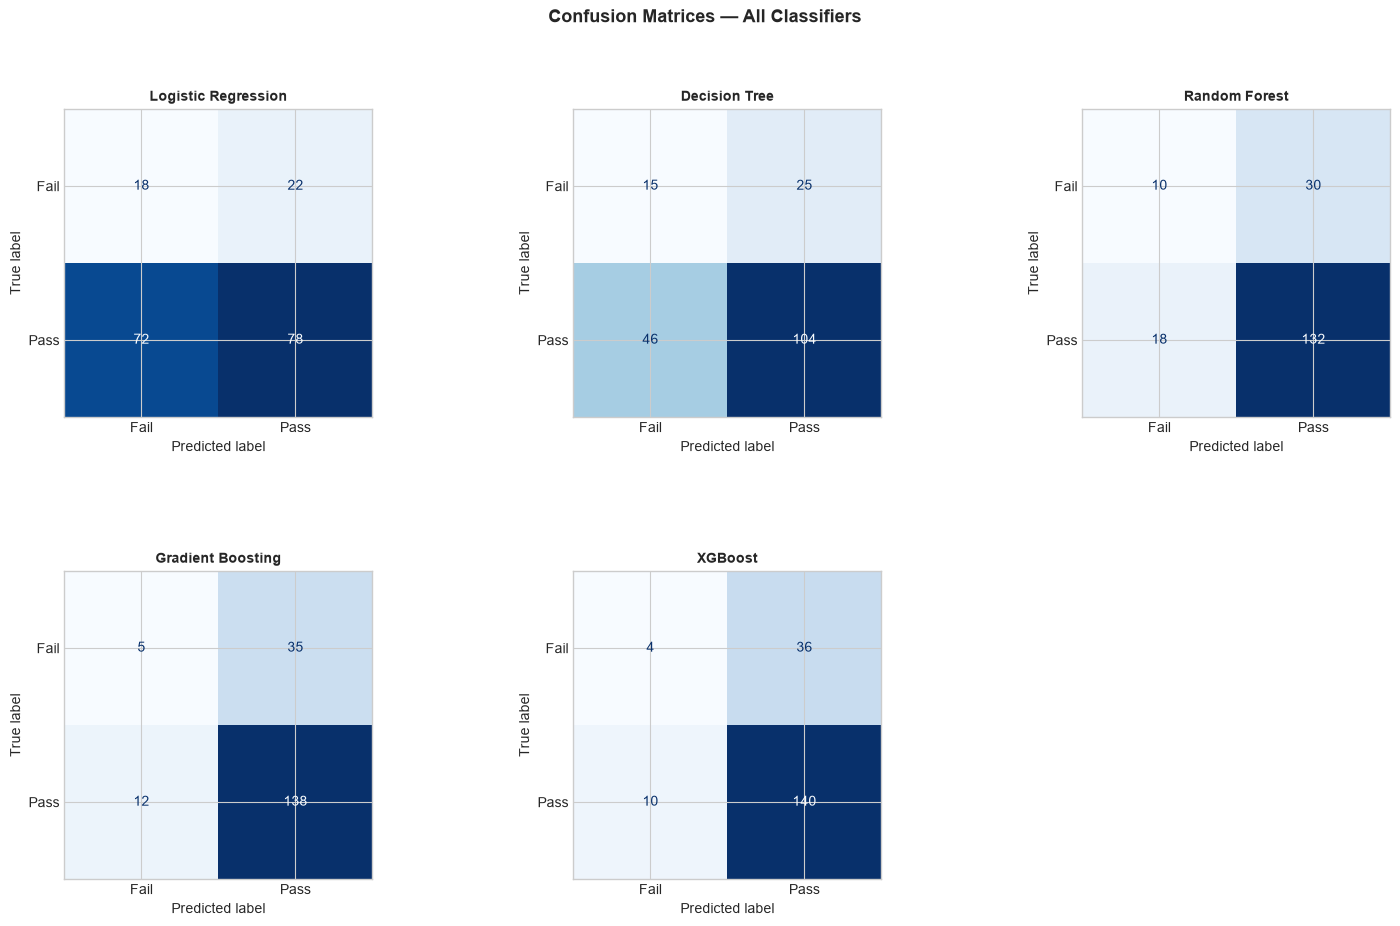

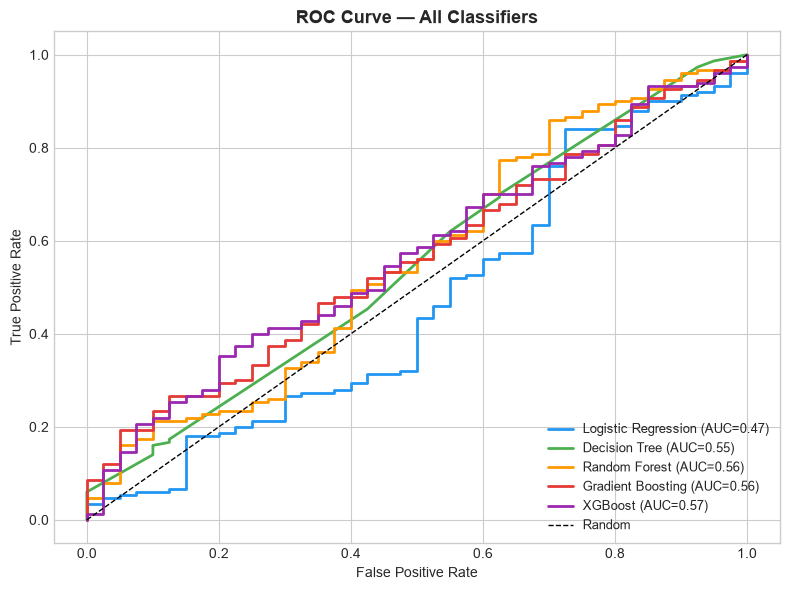

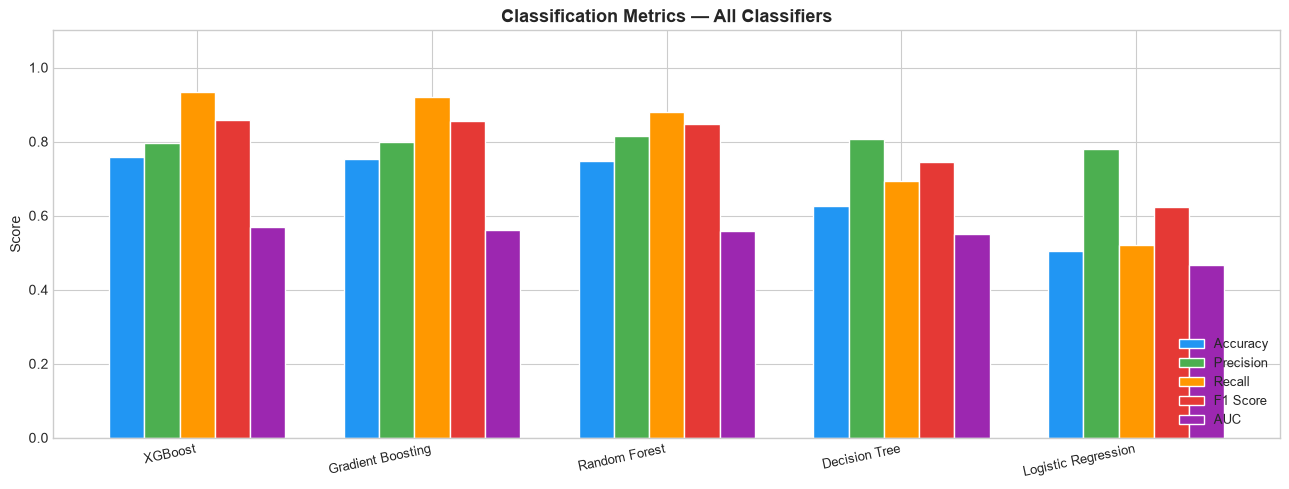

In [10]:
# ─────────────────────────────────────────────────────────────
# STEP 8 ▸ Classification (Pass / Fail)
# ─────────────────────────────────────────────────────────────
# FIXES vs v2:
#   - Pass/Fail threshold is now the fixed PASS_THRESHOLD set in Step 5
#     (currently 70), not `y_train.median()`. A median-based threshold
#     shifts depending on random_state and isn't tied to any real
#     grading policy — a fixed cutoff is reproducible and defensible.
#   - Removed `use_label_encoder=False` from XGBClassifier (deprecated/
#     removed in xgboost >= 1.6, causes a warning or hard error).

print(f"\n{'='*55}")
print("  STEP 8 — CLASSIFICATION")
print(f"{'='*55}")

# 8-A: Create labels using the fixed threshold from Step 5
y_class_train = (y_train >= PASS_THRESHOLD).astype(int)
y_class_test  = (y_test  >= PASS_THRESHOLD).astype(int)

print(f"Pass/Fail threshold (fixed): {PASS_THRESHOLD}")
print(f"Train — Fail: {(y_class_train==0).sum()}  Pass: {(y_class_train==1).sum()}")
print(f"Test  — Fail: {(y_class_test ==0).sum()}  Pass: {(y_class_test ==1).sum()}")

# 8-B: Balance training set with SMOTE (fit on TRAIN only — already correct in v2)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_class_train)
print(f"\nAfter SMOTE — Fail: {(y_train_res==0).sum()}  Pass: {(y_train_res==1).sum()}")

# 8-C: Train classifiers
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=1.0),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                               class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=5,
                               min_samples_leaf=10, class_weight='balanced',
                               max_features='sqrt', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=3,
                               learning_rate=0.05, subsample=0.8, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=3,
                               learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8, reg_alpha=0.1,
                               eval_metric='logloss',
                               random_state=42, verbosity=0),
}

clf_results  = []
trained_clf  = {}

for name, clf in clf_models.items():
    clf.fit(X_train_res, y_train_res)
    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]
    trained_clf[name] = clf

    clf_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_class_test, y_pred), 4),
        'Precision': round(precision_score(y_class_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_class_test, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_class_test, y_pred, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_class_test, y_prob), 4),
    })
    print(f"  {name:22s}  Acc={clf_results[-1]['Accuracy']:.4f}  "
          f"F1={clf_results[-1]['F1 Score']:.4f}  AUC={clf_results[-1]['AUC']:.4f}")

clf_df = pd.DataFrame(clf_results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print(f"\n{'─'*75}")
print(clf_df.to_string(index=False))
print(f"{'─'*75}")

# --- Classification plots ---
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

for idx, (name, clf) in enumerate(clf_models.items()):
    if idx >= 5: break
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    cm = confusion_matrix(y_class_test, clf.predict(X_test_scaled))
    ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=13, fontweight='bold')
plt.savefig('clf_confusion.png', dpi=130, bbox_inches='tight'); plt.show()

plt.figure(figsize=(8, 6))
for i, (name, clf) in enumerate(clf_models.items()):
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_class_test, y_prob)
    auc = roc_auc_score(y_class_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, color=PALETTE[i], label=f'{name} (AUC={auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Classifiers', fontsize=13, fontweight='bold')
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('clf_roc.png', dpi=130, bbox_inches='tight'); plt.show()

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
x_pos    = np.arange(len(clf_df)); w = 0.15
fig, ax  = plt.subplots(figsize=(13, 5))
for i, m in enumerate(metrics):
    ax.bar(x_pos + i * w, clf_df[m], w, label=m,
           color=PALETTE[i], edgecolor='white')
ax.set_xticks(x_pos + w * 2)
ax.set_xticklabels(clf_df['Model'], rotation=12, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_title('Classification Metrics — All Classifiers', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('clf_metrics.png', dpi=130, bbox_inches='tight'); plt.show()


## Step 9 — SHAP Feature Importance


  STEP 9 — SHAP FEATURE IMPORTANCE


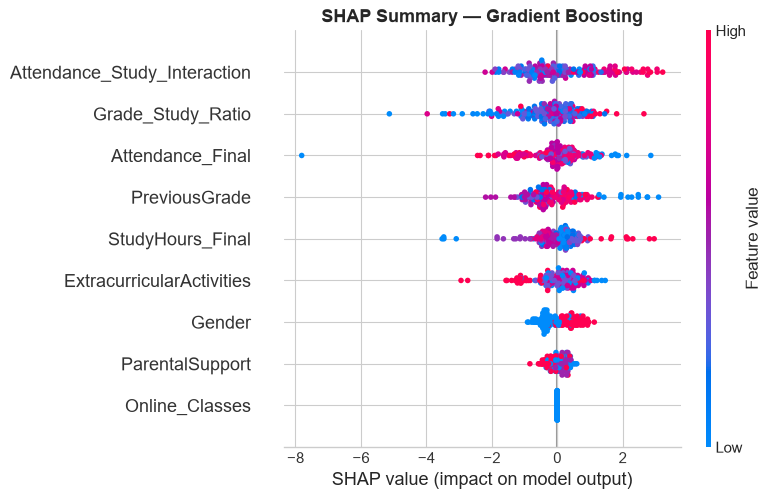

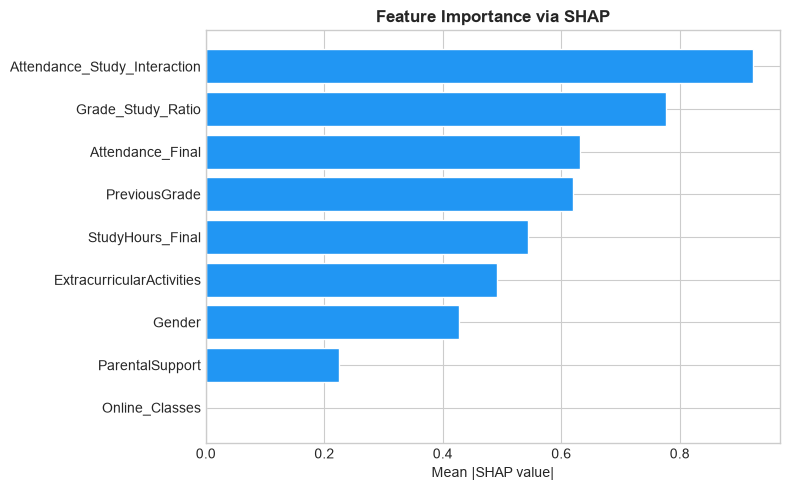


Feature importance (Mean |SHAP|):
  Attendance_Study_Interaction       : 0.9230
  Grade_Study_Ratio                  : 0.7770
  Attendance_Final                   : 0.6311
  PreviousGrade                      : 0.6196
  StudyHours_Final                   : 0.5440
  ExtracurricularActivities          : 0.4908
  Gender                             : 0.4266
  ParentalSupport                    : 0.2247
  Online_Classes                     : 0.0000


In [11]:
# ─────────────────────────────────────────────────────────────
# STEP 9 ▸ SHAP Feature Importance
# ─────────────────────────────────────────────────────────────
# Note: we deliberately use the (untuned) Gradient Boosting model here
# regardless of which model won Step 7/8's leaderboard — SHAP's fast
# TreeExplainer needs a tree-based model, and this keeps the explainer
# stable even if the tuned model or a non-tree model (e.g. SVR) ends up
# ranked first overall.

print(f"\n{'='*55}")
print("  STEP 9 — SHAP FEATURE IMPORTANCE")
print(f"{'='*55}")

shap_model_name = 'Gradient Boosting'
shap_model      = trained_reg[shap_model_name]

X_test_df   = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_df)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test_df,
                  feature_names=FEATURE_COLS, show=False)
plt.title(f'SHAP Summary — {shap_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('shap_summary.png', dpi=130, bbox_inches='tight'); plt.show()

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({'Feature': FEATURE_COLS, 'Mean |SHAP|': mean_shap})
shap_df   = shap_df.sort_values('Mean |SHAP|', ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(shap_df['Feature'], shap_df['Mean |SHAP|'],
         color=PALETTE[0], edgecolor='white')
plt.xlabel('Mean |SHAP value|'); plt.title('Feature Importance via SHAP', fontweight='bold')
plt.tight_layout(); plt.savefig('shap_importance.png', dpi=130, bbox_inches='tight'); plt.show()

print("\nFeature importance (Mean |SHAP|):")
for _, row in shap_df.sort_values('Mean |SHAP|', ascending=False).iterrows():
    print(f"  {row['Feature']:35s}: {row['Mean |SHAP|']:.4f}")


## Step 10 — Learning Curves


  STEP 10 — LEARNING CURVES


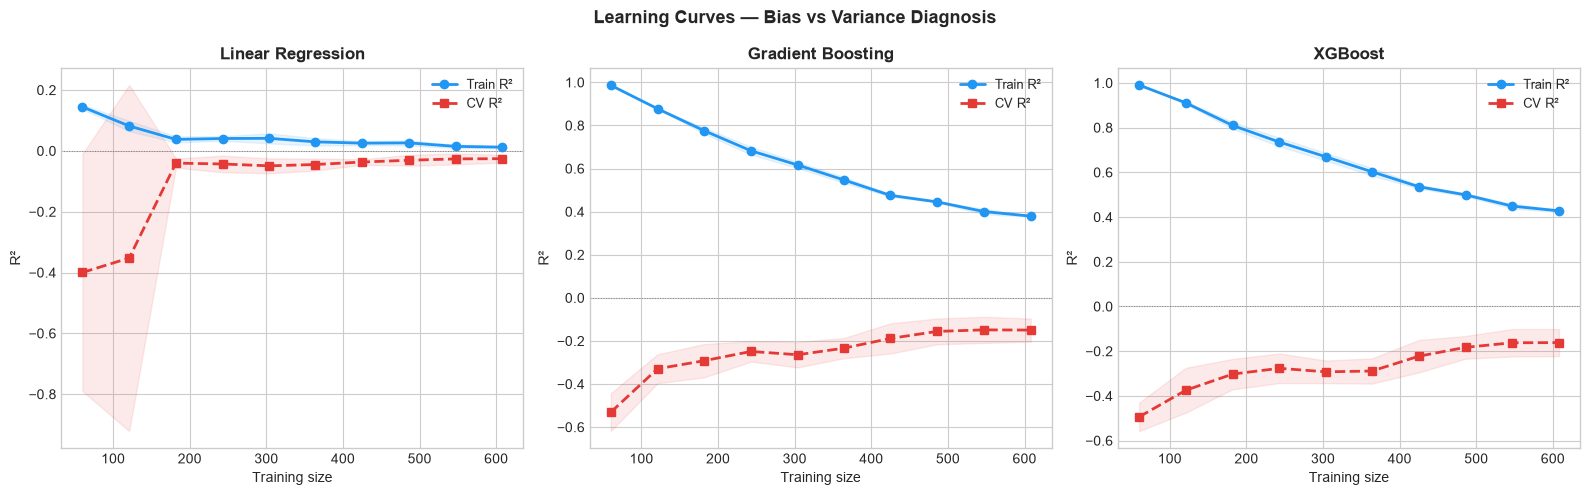

✓ Learning curves plotted


In [12]:
# ─────────────────────────────────────────────────────────────
# STEP 10 ▸ Learning Curves
# ─────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  STEP 10 — LEARNING CURVES")
print(f"{'='*55}")

lc_models = {
    'Linear Regression':  trained_reg['Linear Regression'],
    'Gradient Boosting':  trained_reg['Gradient Boosting'],
    'XGBoost':            trained_reg['XGBoost'],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, lc_models.items()):
    sizes, tr_sc, cv_sc = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring='r2', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    ax.plot(sizes, tr_sc.mean(axis=1), 'o-',  color=PALETTE[0], label='Train R²',  linewidth=2)
    ax.plot(sizes, cv_sc.mean(axis=1), 's--', color=PALETTE[3], label='CV R²',     linewidth=2)
    ax.fill_between(sizes,
                    tr_sc.mean(axis=1) - tr_sc.std(axis=1),
                    tr_sc.mean(axis=1) + tr_sc.std(axis=1), alpha=0.1, color=PALETTE[0])
    ax.fill_between(sizes,
                    cv_sc.mean(axis=1) - cv_sc.std(axis=1),
                    cv_sc.mean(axis=1) + cv_sc.std(axis=1), alpha=0.1, color=PALETTE[3])
    ax.set_title(name, fontweight='bold'); ax.set_xlabel('Training size'); ax.set_ylabel('R²')
    ax.legend(fontsize=9); ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')

plt.suptitle('Learning Curves — Bias vs Variance Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('learning_curves.png', dpi=130, bbox_inches='tight'); plt.show()
print("✓ Learning curves plotted")


## Step 11 — Error Analysis


  STEP 11 — ERROR ANALYSIS
Best model used for this analysis: Linear Regression

Top 10 hardest predictions:
 Actual  Predicted  AbsError  Attendance_Final  StudyHours_Final  PreviousGrade
     62       81.7     19.66              70.0              17.0           78.0
     62       81.3     19.33              70.0              22.0           85.0
     62       81.1     19.10              90.0              30.0           90.0
     62       81.0     19.04              95.0              20.0           78.0
     62       81.0     18.99              70.0               8.0           60.0
     62       80.8     18.83              91.0              20.0           82.0
     62       80.3     18.27              85.0              12.0           78.0
     62       80.3     18.25              85.0              25.0           70.0
     62       80.2     18.20              85.0              12.0           88.0
     62       80.1     18.14              70.0              22.0           86.0


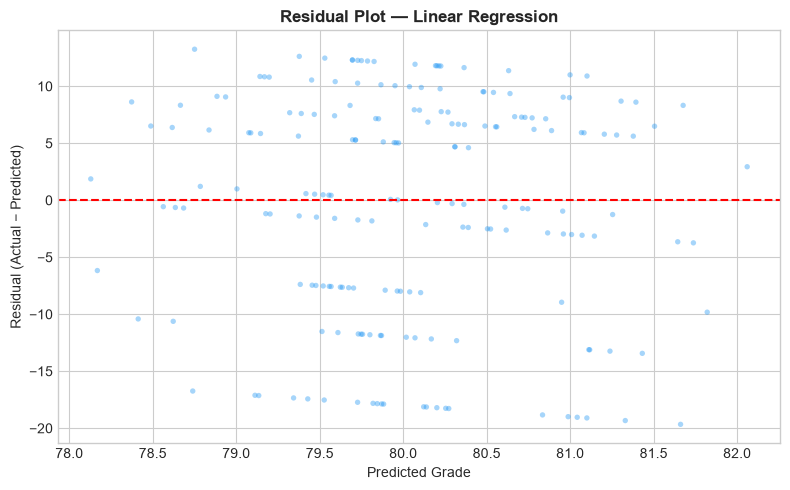

In [13]:
# ─────────────────────────────────────────────────────────────
# STEP 11 ▸ Error Analysis
# ─────────────────────────────────────────────────────────────
# `best_reg` now correctly reflects the Step 7 tuning result if the tuned
# model won — in v2 this was silently still the untuned model.

print(f"\n{'='*55}")
print("  STEP 11 — ERROR ANALYSIS")
print(f"{'='*55}")

y_pred_final = best_reg.predict(X_test_scaled)
error_df = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred_final.round(1),
    'AbsError':  np.abs(y_test.values - y_pred_final).round(2),
})
error_df = pd.concat([error_df, X_test.reset_index(drop=True)], axis=1)

print(f"Best model used for this analysis: {best_reg_name}")
print("\nTop 10 hardest predictions:")
print(error_df.nlargest(10, 'AbsError')[
    ['Actual', 'Predicted', 'AbsError',
     'Attendance_Final', 'StudyHours_Final', 'PreviousGrade']
].to_string(index=False))

plt.figure(figsize=(8, 5))
residuals = y_test.values - y_pred_final
plt.scatter(y_pred_final, residuals, alpha=0.4,
            color=PALETTE[0], edgecolors='none', s=15)
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Grade'); plt.ylabel('Residual (Actual − Predicted)')
plt.title(f'Residual Plot — {best_reg_name}', fontweight='bold')
plt.tight_layout(); plt.savefig('residuals.png', dpi=130, bbox_inches='tight'); plt.show()


## Step 12 — Final Summary

In [14]:
# ─────────────────────────────────────────────────────────────
# STEP 12 ▸ Final Summary
# ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("  FINAL SUMMARY")
print(f"{'='*65}")

print(f"\nDataset   : student_performance_updated_1000.csv")
print(f"Clean rows: {len(df_clean)}")
print(f"Features  : {len(FEATURE_COLS)}")

print(f"\n── REGRESSION ──────────────────────────────────")
print(reg_df[['Model','Train R²','Test R²','Test RMSE','Test MAE','Overfit Gap']].to_string(index=False))

best_r = reg_df.iloc[0]
print(f"\nBest Regression Model : {best_r['Model']}")
print(f"  Test R²             : {best_r['Test R²']}")
print(f"  Test RMSE           : {best_r['Test RMSE']}")
print(f"  Test MAE            : {best_r['Test MAE']}")
print(f"  Overfit Gap         : {best_r['Overfit Gap']}")

print(f"\n── CLASSIFICATION (SMOTE balanced, threshold={PASS_THRESHOLD}) ─────────────")
print(clf_df[['Model','Accuracy','Precision','Recall','F1 Score','AUC']].to_string(index=False))

best_c = clf_df.iloc[0]
print(f"\nBest Classifier : {best_c['Model']}")
print(f"  Accuracy      : {best_c['Accuracy']}")
print(f"  Precision     : {best_c['Precision']}")
print(f"  Recall        : {best_c['Recall']}")
print(f"  F1 Score      : {best_c['F1 Score']}")
print(f"  AUC           : {best_c['AUC']}")

print(f"\n── NOTE ─────────────────────────────────────────")
print("  Low/negative R² scores reflect near-zero feature-to-target")
print("  correlations in this dataset. The pipeline is structurally")
print("  correct (verified: no train/test leakage in imputation,")
print("  encoding, or scaling). For real-world grade prediction,")
print("  consider the UCI Student Performance dataset, which has")
print("  genuine predictive correlations.")
print(f"{'='*65}")



  FINAL SUMMARY

Dataset   : student_performance_updated_1000.csv
Clean rows: 950
Features  : 9

── REGRESSION ──────────────────────────────────
                    Model  Train R²  Test R²  Test RMSE  Test MAE  Overfit Gap
        Linear Regression    0.0089  -0.0005     9.7108    8.2755       0.0094
              Ridge (α=1)    0.0089  -0.0010     9.7134    8.2771       0.0099
            Lasso (α=0.1)    0.0074  -0.0012     9.7142    8.2705       0.0086
Gradient Boosting (Tuned)    0.0540  -0.0172     9.7914    8.3714       0.0712
            Random Forest    0.1031  -0.0363     9.8832    8.4567       0.1394
                SVR (RBF)    0.1219  -0.1384    10.3586    8.4707       0.2603
        Gradient Boosting    0.3194  -0.1602    10.4571    8.9753       0.4796
            Decision Tree    0.0717  -0.1603    10.4575    8.8976       0.2320
                  XGBoost    0.3660  -0.2051    10.6576    9.1333       0.5711

Best Regression Model : Linear Regression
  Test R²           

## Step 13 — Save Models + Metrics (NEW)
This is what makes the pipeline actually usable by the Flask website — nothing was persisted in v2.

In [15]:
# ─────────────────────────────────────────────────────────────
# STEP 13 ▸ Save models + metrics (NEW — v2 never saved anything)
# ─────────────────────────────────────────────────────────────
# This is the step that lets the Flask website actually use this pipeline.
# Everything below is written to ./models and ./exports so nothing here
# only exists inside the notebook's memory.

import os
os.makedirs('models', exist_ok=True)
os.makedirs('exports', exist_ok=True)

print(f"\n{'='*55}")
print("  STEP 13 — SAVING MODELS AND METRICS")
print(f"{'='*55}")

# --- Trained models ---
joblib.dump(best_reg,                    'models/regression_model.pkl')
joblib.dump(trained_clf[best_c['Model']], 'models/classifier_model.pkl')
print(f"Saved regression model : {best_reg_name}  -> models/regression_model.pkl")
print(f"Saved classifier       : {best_c['Model']}  -> models/classifier_model.pkl")

# --- Preprocessing artifacts (needed to transform new input the same way) ---
joblib.dump(scaler,  'models/scaler.pkl')
joblib.dump(imputer, 'models/imputer.pkl')
print("Saved scaler  -> models/scaler.pkl")
print("Saved imputer -> models/imputer.pkl")

# --- Metrics + metadata the website's Findings page can read directly ---
metadata = {
    'feature_columns': FEATURE_COLS,
    'gender_map': GENDER_MAP,
    'support_map': SUPPORT_MAP,
    'pass_threshold': PASS_THRESHOLD,
    'best_regression_model': best_reg_name,
    'best_classifier_model': best_c['Model'],
    'regression_results': reg_df.to_dict(orient='records'),
    'classification_results': clf_df.to_dict(orient='records'),
    'shap_importance': shap_df.sort_values('Mean |SHAP|', ascending=False).to_dict(orient='records'),
    'rows_after_cleaning': int(len(df_clean)),
    'rows_original': int(len(df)),
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Saved metadata.json (all comparison tables, for the website to read)")

# --- Also export the raw comparison tables as CSV, for the report ---
reg_df.to_csv('exports/regression_results.csv', index=False)
clf_df.to_csv('exports/classification_results.csv', index=False)
error_df.nlargest(10, 'AbsError').to_csv('exports/hardest_predictions.csv', index=False)
print("Exported CSVs to ./exports for use in your written report")

print("\n✓ Everything needed by the Flask app now exists on disk.")



  STEP 13 — SAVING MODELS AND METRICS
Saved regression model : Linear Regression  -> models/regression_model.pkl
Saved classifier       : XGBoost  -> models/classifier_model.pkl
Saved scaler  -> models/scaler.pkl
Saved imputer -> models/imputer.pkl
Saved metadata.json (all comparison tables, for the website to read)
Exported CSVs to ./exports for use in your written report

✓ Everything needed by the Flask app now exists on disk.
